# Problem B: Solve Pressure Field in 2D Heterogeneous Porous Media

Consider a square domain $\Omega = [0,1]^2$ representing a heterogeneous porous medium composed of two distinct material phases with significantly different permeabilities, for instance, high-permeability sandstone inclusions embedded in a low-permeability mudstone matrix. Such heterogeneous structures arise frequently in subsurface flow engineering, including groundwater modeling, hydrocarbon reservoir simulation, and fuel cell design. Near the interface between the two phases, the pressure gradient exhibits sharp transitions, making this a classical benchmark for testing the robustness of PDE solvers under non-smooth coefficients.

The permeability field $\mu(x)$ is defined as:

$$
\mu(x) =
\begin{cases}
\mu_1 = 10, & x \in \Omega_1 \quad \text{(high-permeability phase, e.g., sandstone)} \\
\mu_2 = 2,  & x \in \Omega_2 \quad \text{(low-permeability phase, e.g., mudstone)}
\end{cases}
$$

The specific two-phase microstructure (i.e., the geometric distribution of $\Omega_1$ and $\Omega_2$) is provided in the dataset. The pressure field $u(x)$ satisfies the following Darcy flow equation:

$$
-\nabla \cdot \left(\mu(x)\,\nabla u\right) = f, \quad x \in \Omega \tag{1}
$$

where
- $u(x):$ pressure field in the porous medium
- $\mu(x):$ spatially varying permeability field
- $f = 0:$ source term (no internal source/sink)
- $\Omega = [0,1]^2:$ square computational domain

The boundary conditions are prescribed as follows, driving fluid flow from the high-pressure inlet on the left to the low-pressure outlet on the right:

$$
g_D(x) =
\begin{cases}
1, & x_1 = 0 \quad \text{(left boundary, high-pressure inlet)} \\
0, & x_1 = 1 \quad \text{(right boundary, low-pressure outlet)} \\
\text{linear interpolation}, & x_2 = 0 \text{ or } 1 \quad \text{(top and bottom boundaries)}
\end{cases}
$$

## Task: Solve the pressure field $u(x)$

In this task, the permeability field $\mu(x)$ is provided as a $128 \times 128$ pixel matrix — that is, the domain is subdivided into $128 \times 128$ cells, each with a constant permeability value. Using this permeability field, apply a suitable method introduced in the lecture to solve for the pressure field $u(x)$ in the heterogeneous porous medium.

### The Goals
- Please select a suitable deep learning method for solving this forward problem to compute the pressure field $u(x)$, and explain the reason for using it.
- Report your setups for the implementation, such as network structure, activation function, optimizer (with learning rate), epoch (with batch size), loss weights, and other tricks that are used for improvement.
- Compute the $L^2$ relative error (on the testing dataset) at each training epoch and plot the `Error vs. epoch` curve (and report the final error). The $L^2$ relative error between the prediction $u_\text{pred}$ and the reference $u_\text{true}$ is defined as follows:

$$
\text{error} = \sqrt{\frac{\sum_i^n \left| u_\text{pred}(x_i) - u_\text{true}(x_i) \right|^2}{\sum_i^n \left| u_\text{true}(x_i) \right|^2}}
$$

- Plot the predicted solution (and the ground truth reference) and the pointwise absolute error using separate figures with `matplotlib`.

### Dataset

The permeability field and the reference solution are provided in the dataset `ProblemB_dataset.h5`:

- `mu_field`: the permeability field $\mu(x)$, represented as a $128 \times 128$ pixel matrix, where each cell has a constant permeability value (available for training)
- `x_test`: the locations where the reference solution is evaluated (Used for computing error and should **not** be used for training)
- `u_test`: the reference pressure field values (used for computing error and should **not** be used for training)
- Link to dataset: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

x_test: torch.Size([16384, 2]) u_test: torch.Size([128, 128]) mu_field: torch.Size([128, 128])
torch.Size([16384, 1])


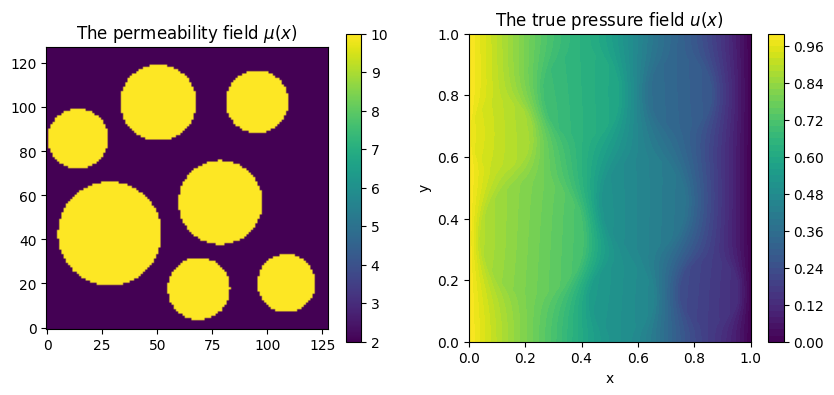

In [1]:
import numpy as np
import torch
import h5py
import matplotlib.pyplot as  plt

# ################################# The testing dataset
with h5py.File('ProblemB_dataset.h5', 'r') as f:
    x_test = torch.tensor(np.array(f['x_test']), dtype=torch.float32)
    u_test = torch.tensor(np.array(f['u_test']), dtype=torch.float32) # Should not be used for training !!!
    mu_field = torch.tensor(np.array(f['mu_field']), dtype=torch.float32)
print('x_test:', x_test.shape, 'u_test:', u_test.shape, 'mu_field:', mu_field.shape)
#
def fun_mu(x, mu=mu_field, resolution=128):
    '''The material property field (get values of material field on any given position x)
    Input:
        x: size(N, 2)
    '''
    mu = mu.reshape(1,-1).to(x)
    delta = 1./(resolution-1)
    #
    x_loc = torch.floor(x[...,0] / delta + 0.5).int()
    y_loc = torch.floor(x[...,1] / delta + 0.5).int()
    loc = y_loc * resolution + x_loc
    #
    mu_new = mu[torch.arange(mu.shape[0]).unsqueeze(1), loc]
    
    return mu_new.T

mu = fun_mu(x_test)
print(mu.shape) # mu at corresponding coordinate (x1, x2)
# ##################################
fig, axes = plt.subplots(1, 2, figsize=(10,4))
#
cntr = axes[0].imshow(mu.reshape(128,128), origin='lower')
axes[0].set_title(r'The permeability field $\mu(x)$')
plt.colorbar(cntr)
#
cntr = axes[1].contourf(x_test[:,0].reshape(128, 128), x_test[:,1].reshape(128, 128), u_test, levels=50)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title(r'The true pressure field $u(x)$')
plt.colorbar(cntr)
plt.show()

In [2]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
from torch.autograd import grad, Variable
from torch.utils.data import Dataset, DataLoader
from tqdm import trange
import time


In [3]:
def setup_seed(seed):
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

setup_seed(3407)
device = ("cuda" if torch.cuda.is_available() else "cpu")
print(device)
dtype = torch.float32
N_mesh = 128

cuda


In [4]:
x_test=x_test.to(device)
u_test=u_test.to(device)
mu_field=mu_field.to(device)
def get_data(x_test, u_test, mu_field):
    mu_grid = mu.reshape(1,128,128,1).to(device)
    u_grid = u_test.reshape(1,128,128,1).to(device)
    x_grid = x_test.reshape(1,128,128,2).to(device)
    ax = torch.cat([mu_grid, x_grid], dim=-1).to(device)
    return ax, u_grid, x_test

ax, u_grid, x_test = get_data(x_test,u_test,mu_field)
print(ax.shape)
print(u_grid.shape)
print(x_test.shape)
#print(ax.device)
#print(u_grid.device)
print(f"Max true pressure: {u_test.max().item()}")
print(f"Min true pressure: {u_test.min().item()}")

torch.Size([1, 128, 128, 3])
torch.Size([1, 128, 128, 1])
torch.Size([16384, 2])
Max true pressure: 1.0
Min true pressure: 0.0


In [5]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_size, out_size, modes1, modes2, dtype):
        super(SpectralConv2d, self).__init__()
        self.in_size = in_size
        self.out_size = out_size
        self.modes1 = modes1
        self.modes2 = modes2
        self.scale = 1. /(in_size*out_size)
        ctype = torch.complex64 if (dtype is None or dtype == torch.float32) else torch.complex128
        self.weight1  = nn.Parameter(self.scale * torch.rand(in_size, out_size, modes1, modes2, dtype=ctype))
        self.weight2  = nn.Parameter(self.scale * torch.rand(in_size, out_size, modes1, modes2, dtype=ctype))

    def compl_mul_2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batch_size = x.shape[0]
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(batch_size, self.out_size, x.size(-2), x.size(-1)//2+1, device = x.device, dtype=torch.cfloat )
        out_ft[:,:,:self.modes1,:self.modes2] = self.compl_mul_2d(x_ft[:, :,  :self.modes1, :self.modes2], self.weight1)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul_2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weight2)
        return torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        


In [6]:
class FNO2d(nn.Module):
    def __init__(self, in_size, out_size, modes1, modes2, hidden_list, dtype=None):
        super(FNO2d, self).__init__()
    
        self.hidden_list = hidden_list
        self.hidden_in = hidden_list[0]
        self.activation = nn.ReLU()
        self.fc_in = nn.Linear(in_size, hidden_list[0], dtype=dtype)

        conv_net, w_net = [],[]
        for hidden in hidden_list[1:]:
            conv_net.append(SpectralConv2d(self.hidden_in, hidden, modes1, modes2, dtype))
            w_net.append(nn.Conv1d(self.hidden_in, hidden, 1, dtype=dtype))
            self.hidden_in = hidden

        self.spectral_conv = nn.ModuleList(conv_net)
        self.weight_conv = nn.ModuleList(w_net)

        self.fc_out0 = nn.Linear(self.hidden_in, 128, dtype=dtype)
        self.fc_out1 = nn.Linear(128, out_size, dtype=dtype)

    def forward(self,ax):
        #print("Inside FNO2d, forward")
        #print("ax shape:", ax.shape)
        batch_size = ax.shape[0]
        mx_size, my_size = ax.shape[1], ax.shape[2]
        ax = self.fc_in(ax).permute(0,3,1,2)
        hidden_last = self.hidden_list[0]

        for conv, weight, hidden_size in zip(self.spectral_conv, self.weight_conv, self.hidden_list[1:]):
            ax1 = conv(ax)
            ax2 = weight(ax.view(batch_size, hidden_last, -1)).view(batch_size, hidden_size, mx_size, my_size)
            ax  = self.activation(ax1 + ax2)
            hidden_last = hidden_size

        ax = ax.permute(0, 2, 3, 1)
        ax = self.activation(self.fc_out0(ax))
        return self.fc_out1(ax)
        
mode1 = 12
mode2 = 12
hidden_list = [64, 64, 64]
print(ax.shape[-1])
print(u_grid.shape[-1])
in_size = ax.shape[-1]
out_size = u_grid.shape[-1]
model_u = FNO2d(in_size, out_size, mode1, mode2, hidden_list).to(device)

total_params  = sum(p.numel() for p in model_u.parameters() if p.requires_grad)
print(f'{total_params:,} trainable parameters.')        
        

3
1
2,376,321 trainable parameters.


In [7]:
class UnitGaussianNormalizer(object):
    
    def __init__(self,ax,eps=1e-8):
        self.mean = torch.mean(ax[...,0:1], dim=[1,2], keepdim=True).to(device)
        self.std=torch.std(ax[...,0:1],dim=[1,2], keepdim=True).to(device)
        self.eps = eps
    def encode(self,ax):
        d = ax.shape[-1] - 1
        #print(d)
        a_norm, x_part = torch.split(ax, [1, d], dim=-1)
        #print("unitgauss, a_norm", a_norm , a_norm.shape)
        #print("unitgauss, x_part", x_part , x_part.shape)
        return torch.cat([(a_norm - self.mean) / (self.std + self.eps), x_part], dim=-1)

    def decode(self,ax):
        d = ax.shape[-1] - 1
        a_norm, x_part = torch.split(ax, [1, d], dim=-1)
        return torch.cat([a_norm * (self.std + self.eps) + self.mean, x_part], dim=-1)


normalizer_ax = UnitGaussianNormalizer(ax.to(device))


In [8]:
class mollifier(object):
    def __init__(self):
        super(mollifier,self).__init__()

    def __call__(self,u,ax):
        x_mesh = ax[...,1:2]
        y_mesh = ax[...,2:3]
        boundaries = 1.0 - x_mesh
        inside = x_mesh*(1.0- x_mesh)*y_mesh*(1.0-y_mesh)
        u = boundaries + (inside*u)

        return u
        

In [9]:
class LossClass(object):
    def __init__(self,u_model,normalizer,lambda_r=1.0, lambda_d=0.0):
        self.u_model = u_model
        self.mollifier = mollifier()
        self.normalizer = normalizer
        self.lambda_r = lambda_r
        self.lambda_d = lambda_d
        self.dx = 1/(N_mesh-1)
        self.dy= 1/(N_mesh-1)

    def predict(self, ax_batch):
        ax_norm = self.normalizer.encode(ax_batch)
        d = ax_batch.shape[-1] - 1
        #print("predict, d", d)
        a_norm, x_part = torch.split(ax_batch, [1,d], dim=-1)
        #print("predict, a_norm", a_norm.shape)
        #print("predict, x_part", x_part.shape)
       #print("predict, ax_batch", ax_batch.shape)
        #print("predict, ax_norm", ax_norm.shape)
        u_pred_0 = self.u_model(ax_norm)
        #print("predict, u_pred_0", u_pred_0.shape)
        u_pred = self.mollifier(u_pred_0, ax_batch)
        #print("predict, u_pred", u_pred.shape)
        return u_pred

    def loss_pde(self,ax_batch):
        #print("losspde, ax_batch", ax_batch.shape)
        # PDE loss with finite volume method
        n_batch = ax_batch.shape[0]
        u = self.predict(ax_batch)
        mu = ax_batch[...,0:1] #mu is a for my problem
        eps = 1e-12
        mu_x_face = 2.0 * mu[:, :, 1:, :] * mu[:, :, :-1, :] / ( mu[:, :, 1:, :] + mu[:, :, :-1, :] + eps)
        mu_y_face = 2.0 * mu[:, 1:, :, :] * mu[:, :-1, :, :] / ( mu[:, 1:, :, :] + mu[:, :-1, :, :] + eps)
        flux_x = mu_x_face * (u[:, :, 1:, :] - u[:, :, :-1, :]) / self.dx
        flux_y = mu_y_face * (u[:, 1:, :, :] - u[:, :-1, :, :]) / self.dy

        # Divergence at interior cells
        dflux_dx = (flux_x[:, 1:-1, 1:, :] - flux_x[:, 1:-1, :-1, :]) / self.dx
        dflux_dy = (flux_y[:, 1:, 1:-1, :] - flux_y[:, :-1, 1:-1, :]) / self.dy
        residual = -(dflux_dx + dflux_dy)
        '''
        # PDE loss with central difference. Gave me Huge error with u_test
        #print("loss_pde, mu_max", torch.max(mu))
        #mu = mu/torch.max(mu)
        dudx = (u[:, 1:-1, 2:,:] - u[:, 1:-1, :-2,:]) /(2 * self.dx)
        dudy = (u[:, 2:, 1:-1,:] - u[:, :-2, 1:-1,:]) /(2 * self.dy)

        mu_dux = mu[:,1:-1,1:-1,:] * dudx 
        mu_duy = mu[:,1:-1,1:-1,:] * dudy

        d_mu_dux_dx = (mu_dux[:, 1:-1, 2:,:] - mu_dux[:, 1:-1, :-2,:]) /(self.dx*2.0) 
        d_mu_duy_dy = (mu_duy[:, 2:, 1:-1,:] - mu_duy[:, :-2, 1:-1,:]) /(self.dy*2.0)  
       
        #left = (- (d_mu_dux_dx + d_mu_duy_dy)).reshape(n_batch, -1)
        #right = torch.zeros_like(left)
        
        #loss = torch.norm(left - right, 2, dim=1)
        residual = -(d_mu_dux_dx + d_mu_duy_dy)
        '''
        return torch.mean(residual**2)

    def loss_data(self,ax_batch, u_batch):
        batch_size = u_batch.shape[0]
        u_pred     = self._predict(ax_batch)                    
        u_true     = u_batch[..., 0]                             
        loss = torch.norm((u_true - u_pred).reshape(batch_size, -1), 2, dim=1)
        #print("Inside Loss_data")
        #print("batch_size", batch_size.shape)
        #print("u_pred", u_pred.shape)
        #print("u_true", u_true.shape)
        return torch.mean(loss)

    def loss_total(self, ax_batch, u_batch=None):
        loss_pde = self.loss_pde(ax_batch)
        loss = self.lambda_r  * loss_pde
        if self.lambda_d > 0 and u_batch is not None:
            loss = loss + self.lambda_d * self.loss_data(ax_batch, u_batch)
        #print("loss_total, pde loss", loss_pde)
        return loss

    def get_error(self, ax, u):
        batch_size = u.shape[0]
        u_pred = self.predict(ax)                    
        #u_true = u[..., 0] created a u_true of shape 128 only
        u_true = u
        nomi = torch.norm((u_pred - u_true).reshape(u_true.shape[0], -1), p=2, dim=1)
        domi = torch.norm(u_true.reshape(u_true.shape[0], -1), p=2, dim=1)
        rel_l2 = nomi/domi
        return torch.mean(rel_l2)
        
        
        
        

In [10]:
class MyDataset(Dataset):
    def __init__(self, ax: torch.Tensor, u: torch.Tensor = None):
        self.ax = ax
        self.u  = u

    def __getitem__(self, index):
        if self.u is not None:
            return self.ax[index], self.u[index]
        return (self.ax[index],)

    def __len__(self):
        #print(self.ax.shape[0])
        return self.ax.shape[0]

In [11]:
LAMBDA_R = 1.0    
LAMBDA_D = 0.0   

train_dataset = MyDataset(ax)
#train_dataset.__len__
#print(train_dataset.__len__)
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=False)

lossClass = LossClass(u_model=model_u,normalizer=normalizer_ax,lambda_r=LAMBDA_R,lambda_d=LAMBDA_D)

epochs    = 7000
lr        = 5e-5
optimizer = torch.optim.Adam(model_u.parameters(), lr=lr, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.7)

In [12]:
from pathlib import Path
from datetime import datetime
import json
import csv
def create_experiment_dir(base_dir="experiments", name="pressure_field_PINO"):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    exp_dir = Path(base_dir) / f"{name}_{timestamp}"
    exp_dir.mkdir(parents=True, exist_ok=True)

    (exp_dir / "figures").mkdir(exist_ok=True)
    (exp_dir / "checkpoints").mkdir(exist_ok=True)
    (exp_dir / "arrays").mkdir(exist_ok=True)

    return exp_dir

exp_dir = create_experiment_dir(name="pressure_field_PINO")
print("Saving experiment to:", exp_dir)

Saving experiment to: experiments\pressure_field_PINO_20260710_124757


In [13]:
metrics_path = exp_dir / "metrics.csv"

with open(metrics_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "pde_loss", "l2_error", "learning_rate"])

In [14]:
config = {
    "N_mesh": N_mesh,
    "epochs": epochs,
    "learning_rate": lr,
    "modes1": mode1,
    "modes2": mode2,
    "hidden_list": hidden_list,
    "lambda_r": LAMBDA_R,
    "lambda_d": LAMBDA_D,
    "optimizer": "Adam",
    "scheduler": str(scheduler),
    "problem": "PINO for pressure_field",
    "mu_values": [2, 10],
}

with open(exp_dir / "config.json", "w") as f:
    json.dump(config, f, indent=4)

In [15]:
loss_list, error_list = [], []
t0 = time.time()
best_error = float("inf")
best_epoch = 0
best_pde_loss = None
for epoch in trange(epochs):
    model_u.train()
    epoch_loss = 0.0

    for batch in train_loader:
        ax_batch = batch[0].to(device)
        #mu_batch = ax_batch[...,0]
        
        #if epoch == 0:
            #print(f"X1 Min: {ax_batch[..., 1].min():.4f}, Max: {ax_batch[..., 1].max():.4f}")
            #print(f"X2 Min: {ax_batch[..., 2].min():.4f}, Max: {ax_batch[..., 2].max():.4f}")
            
        #print("mu_min:",mu_batch.min().item())
        #print("mu_max:",mu_batch.max().item())
        #print("unique mu:",torch.unique(mu_batch))
        #print("Dataloader ax_batch shape:", ax_batch.shape)

        optimizer.zero_grad()
        loss_train = lossClass.loss_total(ax_batch)
        torch.nn.utils.clip_grad_norm_(model_u.parameters(), max_norm=1.0)
        loss_train.backward()
        optimizer.step()
        epoch_loss += loss_train.item()

    scheduler.step()
    loss_list.append(epoch_loss)
   
    model_u.eval()
    with torch.no_grad():
        u_test = u_test.reshape(1,N_mesh,N_mesh,1).to(device)
        error = lossClass.get_error(ax_batch.to(device), u_test.to(device))
        error_list.append(error.item())
        if error.item() < best_error:
            best_error = error.item()
            best_epoch = epoch
            best_pde_loss = epoch_loss
        
            torch.save( {
                    "epoch": epoch,
                    "model_state_dict": model_u.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "pde_loss": epoch_loss,
                    "l2_error": error.item(),
                }, "best_model.pt")

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch {epoch+1:4d} | PDE loss: {epoch_loss:.4e} | Test L2 rel. error: {error_list[-1]:.4e} | Best L2: {best_error:.4e} at epoch {best_epoch}')

    current_lr = optimizer.param_groups[0]["lr"]

    with open(metrics_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch, epoch_loss, error.item(), current_lr])

print(f'\nTotal training time: {time.time() - t0:.1f}s')
error_array = np.array(error_list)
loss_array = np.array(loss_list)

best_epoch = int(np.argmin(error_array))
best_error = error_array[best_epoch]
best_loss = loss_array[best_epoch]

print("Best epoch:", best_epoch)
print("Best L2 error:", best_error)
print("PDE loss at best epoch:", best_loss)
print("Final L2 error:", error_array[-1])
print("Final PDE loss:", loss_array[-1])

 14%|█████████▊                                                          | 1010/7000 [00:52<01:17, 77.57it/s]

Epoch 1000 | PDE loss: 4.7633e+02 | Test L2 rel. error: 5.2779e-02 | Best L2: 5.2743e-02 at epoch 965


 29%|███████████████████▏                                               | 2010/7000 [01:02<00:45, 109.97it/s]

Epoch 2000 | PDE loss: 1.6160e+02 | Test L2 rel. error: 5.7665e-02 | Best L2: 5.2743e-02 at epoch 965


 43%|█████████████████████████████▎                                      | 3016/7000 [01:12<00:40, 99.51it/s]

...

Epoch 5000 | PDE loss: 8.9971e+01 | Test L2 rel. error: 6.1763e-02 | Best L2: 5.2743e-02 at epoch 965


 86%|█████████████████████████████████████████████████████████▌         | 6010/7000 [01:38<00:08, 115.18it/s]

Epoch 6000 | PDE loss: 8.5604e+01 | Test L2 rel. error: 6.1781e-02 | Best L2: 5.2743e-02 at epoch 965


100%|████████████████████████████████████████████████████████████████████| 7000/7000 [01:48<00:00, 64.61it/s]

Epoch 7000 | PDE loss: 8.2541e+01 | Test L2 rel. error: 6.1717e-02 | Best L2: 5.2743e-02 at epoch 965

Total training time: 108.3s
Best epoch: 965
Best L2 error: 0.05274291709065437
PDE loss at best epoch: 530.0797729492188
Final L2 error: 0.06171717494726181
Final PDE loss: 82.54073333740234


In [16]:
torch.save(
    {
        "model_state_dict": model_u.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "config": config,
        "loss_list": loss_list,
        "error_list": error_list,
    },
    exp_dir / "checkpoints" / "final_model.pt"
)

In [17]:
checkpoint = torch.load("best_model.pt", map_location=device)
model_u.load_state_dict(checkpoint["model_state_dict"])
model_u.eval()

print("Loaded best model from epoch:", checkpoint["epoch"])
print("Best L2:", checkpoint["l2_error"])
print("Best PDE loss:", checkpoint["pde_loss"])

Loaded best model from epoch: 965
Best L2: 0.05274291709065437
Best PDE loss: 530.0797729492188


In [18]:
def L2_error(u, u_pred):
    nomi = torch.linalg.norm(u - u_pred, dim=1)
    domi = torch.linalg.norm(u, dim=1)
    l2 = nomi/domi
    return l2

In [19]:
print(x_test.shape)
print(x_test.device)

print(u_test.shape)
print(u_test.device)

print(mu_field.shape)
print(mu_field.device)
print(mu_field)
print(torch.unique(mu_field))
print()

torch.Size([16384, 2])
cuda:0
torch.Size([1, 128, 128, 1])
cuda:0
torch.Size([128, 128])
cuda:0
tensor([[2., 2., 2.,  ..., 2., 2., 2.],
        [2., 2., 2.,  ..., 2., 2., 2.],
        [2., 2., 2.,  ..., 2., 2., 2.],
        ...,
        [2., 2., 2.,  ..., 2., 2., 2.],
        [2., 2., 2.,  ..., 2., 2., 2.],
        [2., 2., 2.,  ..., 2., 2., 2.]], device='cuda:0')
tensor([ 2., 10.], device='cuda:0')



In [21]:
model_u.eval()
print(ax)
with torch.no_grad():
    ax = ax.to(device)
    ax_norm = normalizer_ax.encode(ax)
    u_pred_all = model_u(ax_norm)
    u_pred_all = mollifier()(u_pred_all, ax)

    l2_err = L2_error(u_test.reshape(1,N_mesh**2), u_pred_all.reshape(1,N_mesh**2))
    print("The average l2 error:", torch.mean(l2_err))
    

tensor([[[[2.0000, 0.0000, 0.0000],
          [2.0000, 0.0079, 0.0000],
          [2.0000, 0.0157, 0.0000],
          ...,
          [2.0000, 0.9843, 0.0000],
          [2.0000, 0.9921, 0.0000],
          [2.0000, 1.0000, 0.0000]],

         [[2.0000, 0.0000, 0.0079],
          [2.0000, 0.0079, 0.0079],
          [2.0000, 0.0157, 0.0079],
          ...,
          [2.0000, 0.9843, 0.0079],
          [2.0000, 0.9921, 0.0079],
          [2.0000, 1.0000, 0.0079]],

         [[2.0000, 0.0000, 0.0157],
          [2.0000, 0.0079, 0.0157],
          [2.0000, 0.0157, 0.0157],
          ...,
          [2.0000, 0.9843, 0.0157],
          [2.0000, 0.9921, 0.0157],
          [2.0000, 1.0000, 0.0157]],

         ...,

         [[2.0000, 0.0000, 0.9843],
          [2.0000, 0.0079, 0.9843],
          [2.0000, 0.0157, 0.9843],
          ...,
          [2.0000, 0.9843, 0.9843],
          [2.0000, 0.9921, 0.9843],
          [2.0000, 1.0000, 0.9843]],

         [[2.0000, 0.0000, 0.9921],
          [2.0000

In [22]:
print(u_pred_all.shape)

torch.Size([1, 128, 128, 1])


a_show shape: (128, 128)
u_show shape: (128, 128)
u_pred_show shape: (128, 128)


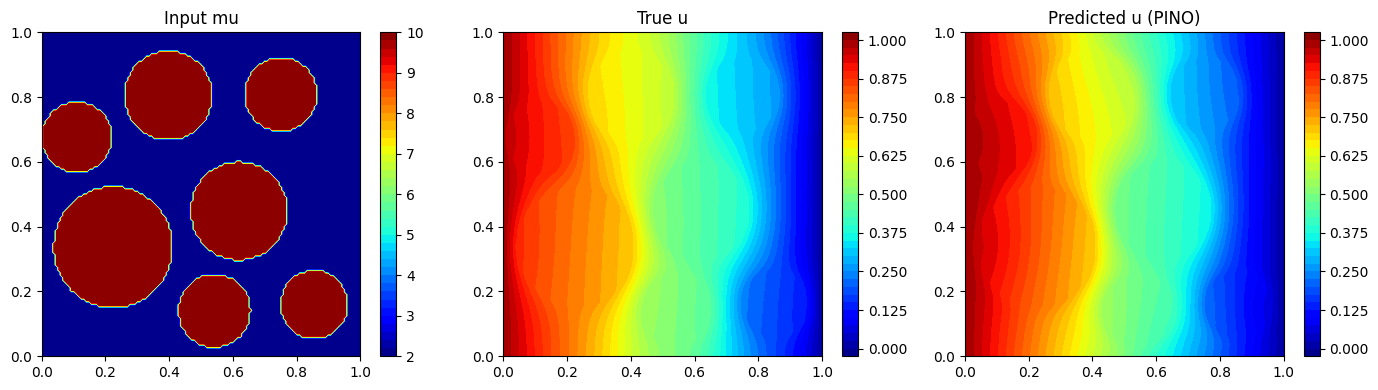

In [23]:
from scipy.interpolate import griddata
sample_idx = 0

a_show      = ax[sample_idx, ..., 0].detach().cpu().numpy()
u_show      = u_test.reshape(N_mesh,N_mesh).detach().cpu().numpy()
u_pred_show = u_pred_all[sample_idx, ..., 0].detach().cpu().numpy()

print("a_show shape:", a_show.shape)
print("u_show shape:", u_show.shape)
print("u_pred_show shape:", u_pred_show.shape)

mesh_plot = np.meshgrid(np.linspace(0, 1, 128), np.linspace(0, 1, 128), indexing="ij")

x_plot, y_plot = mesh_plot[0], mesh_plot[1]

fig, axs = plt.subplots(1, 3, figsize=(14, 4))

for a, vals, title in zip( axs, [a_show, u_show, u_pred_show], ["Input mu", "True u", "Predicted u (PINO)"]):

    method = "nearest" if title == "Input mu" else "cubic"

    z = griddata((x_test[:, 0].detach().cpu().numpy(), x_test[:, 1].detach().cpu().numpy()), vals.ravel(), (x_plot, y_plot), method=method)

    cntr = a.contourf(x_plot, y_plot, z, levels=40, cmap="jet")
    a.set_title(title)
    fig.colorbar(cntr, ax=a)

plt.tight_layout()
fig.savefig(exp_dir / "figures" / "prediction_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig(exp_dir / "figures" / "prediction_comparison.pdf", bbox_inches="tight")
plt.show()

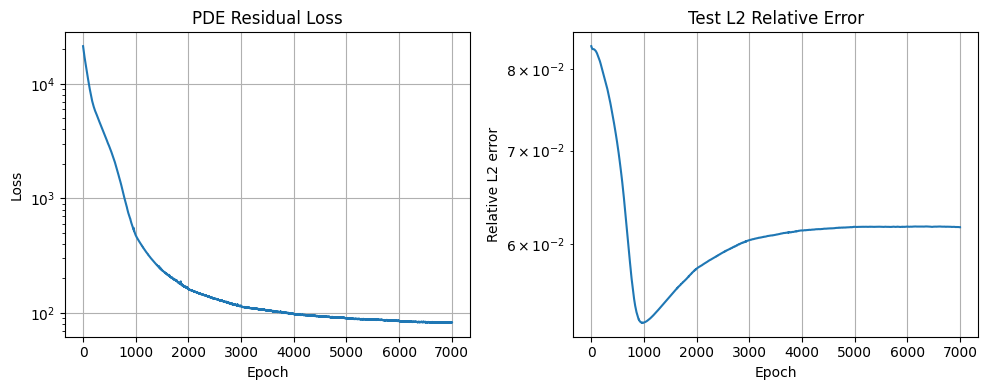

In [24]:
error_array = np.array(error_list)
loss_array = np.array(loss_list)

best_epoch = int(np.argmin(error_array))
best_error = error_array[best_epoch]

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].semilogy(loss_list)
axs[0].set_title("PDE Residual Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].grid(True)

axs[1].semilogy(error_list)
axs[1].set_title("Test L2 Relative Error")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Relative L2 error")
axs[1].grid(True)

plt.tight_layout()

fig.savefig(exp_dir / "figures" / "training_curves.png", dpi=300, bbox_inches="tight")

plt.show()

In [25]:
np.savez(
    exp_dir / "arrays" / "final_fields.npz",
    mu=a_show,
    u_true=u_show,
    u_pred=u_pred_show,
    loss=np.array(loss_list),
    error=np.array(error_list)
)